# A simple Language Model with PyTorch

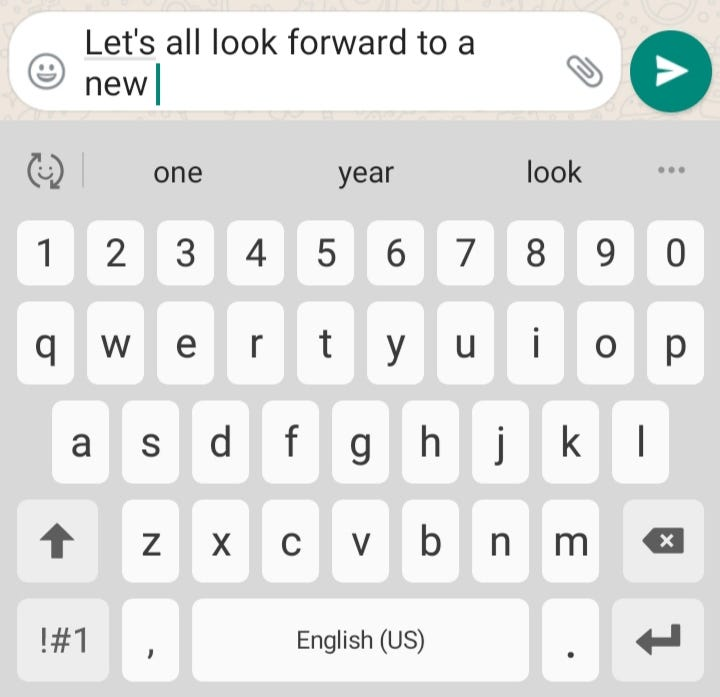

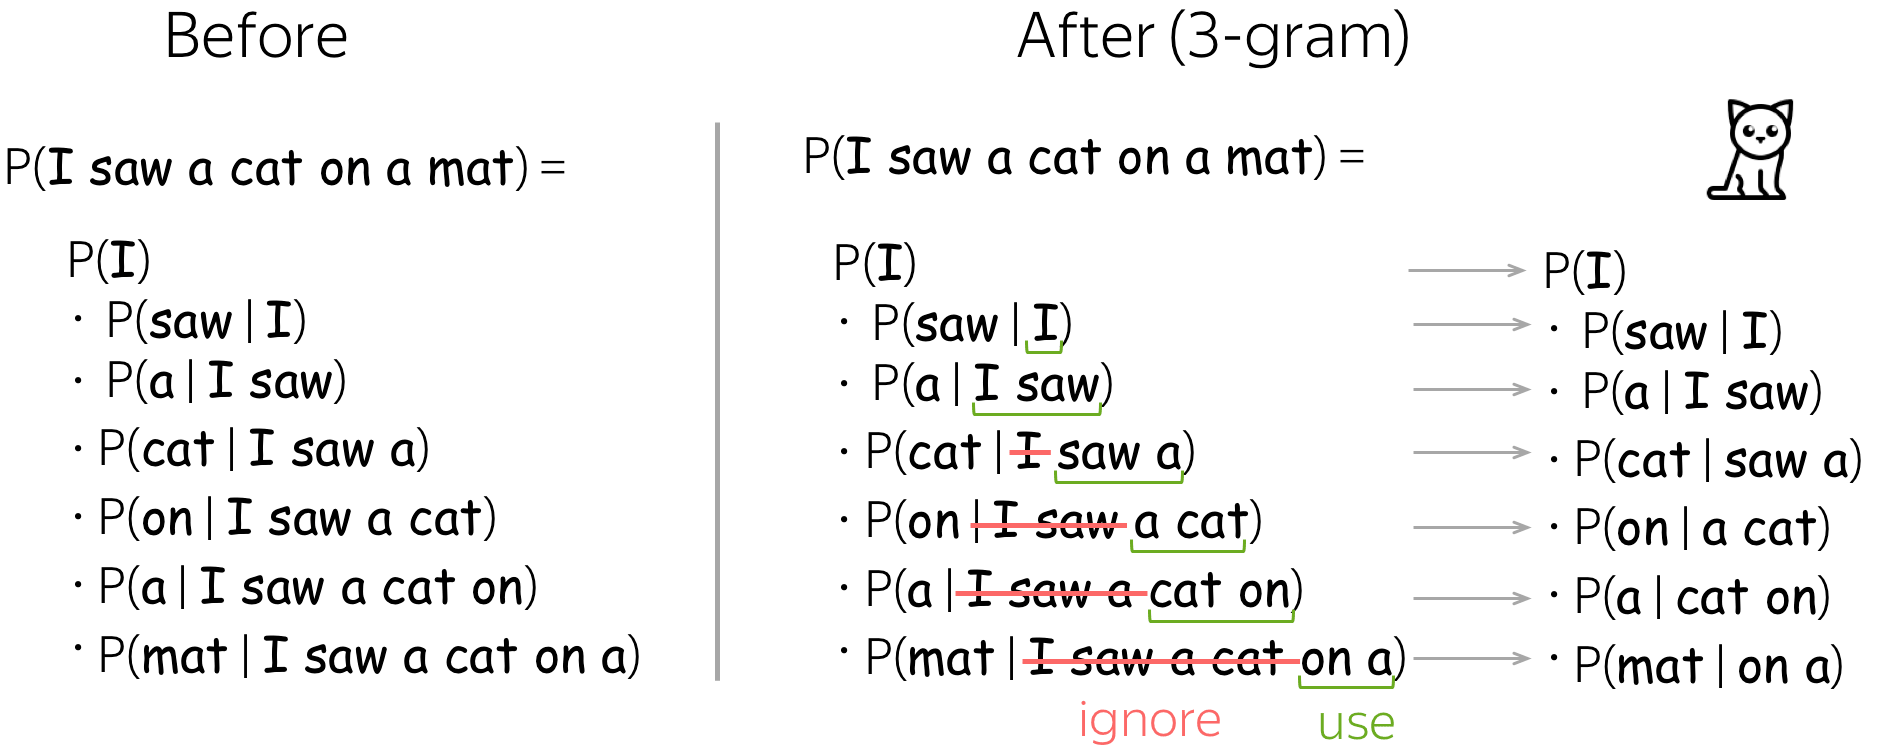

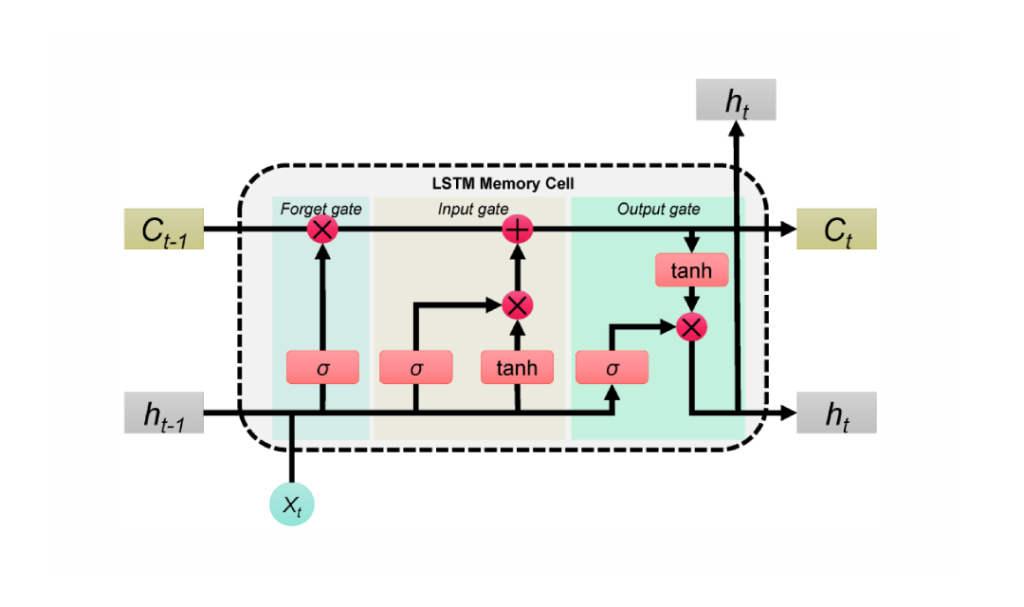

## Import libraries

In [12]:
!pip install datasets==2.15
!pip install huggingface_hub==0.18.0
!pip install nltk
!pip install matplotlib
!pip install collections
!pip install tqdm



  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.5 MB 17.8 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 19.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 19.7 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 16.6 MB/s  0:00:00
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ----------

ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections


In [8]:
# NLTK initialization
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shubham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
# pytorch - https://docs.pytorch.org/tutorials/beginner/basics/intro.html
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# nlp
from datasets import load_dataset
from nltk import word_tokenize

# utils
from matplotlib import pyplot as plt
from collections import Counter
from tqdm import tqdm

## Load and prepare data

In [4]:
# Load and preprocess IMDB data from Hugging Face
dataset = load_dataset("imdb", split="train")

Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
# Count all tokens
counter = Counter()
dataset_tokens = []
for review in dataset:
    review_tokens = word_tokenize(review["text"])
    counter.update(review_tokens)
    dataset_tokens.append(review_tokens)

In [6]:
# Vocabulary class
class Vocab:
    def __init__(self, counter, specials=['<unk>', '<pad>']):
        # idx to str
        self.itos = specials + [word for word, freq in counter.items() if freq>2]
        # str to idx
        self.stoi = {word: idx for idx, word in enumerate(self.itos)}
        self.default_index = self.stoi['<unk>']

    def __getitem__(self, token):
        # word to index
        return self.stoi.get(token, self.default_index)

    def totext(self, indices):
        # indices to string
        return [self.itos[i] for i in indices]

    def __len__(self):
        return len(self.itos)

    def set_default_index(self, index):
        self.default_index = index

vocab = Vocab(counter)
print("Vocabulary size:", len(vocab))

Vocabulary size: 49447


In [7]:
vocab.totext([0, 10000, 1005])

['<unk>', 'bears', 'lack']

In [8]:
dataset_tokens[101]

['Assuming',
 'this',
 'wo',
 "n't",
 'end',
 'up',
 'a',
 'straight-to-video',
 'release',
 ',',
 'I',
 'would',
 'have',
 'to',
 'say',
 'void',
 'this',
 'title',
 'at',
 'all',
 'costs',
 '.',
 'Unless',
 'you',
 "'re",
 'bored',
 'of',
 'good',
 ',',
 'well-executed',
 'movies',
 ',',
 'that',
 'is',
 '.',
 'I',
 'saw',
 'this',
 'last',
 'night',
 'at',
 'AFI',
 'Dallas',
 ',',
 'and',
 'I',
 'left',
 'with',
 '20',
 'minutes',
 'remaining',
 ',',
 'simply',
 'because',
 'I',
 'did',
 "n't",
 'care',
 'anymore',
 '(',
 'about',
 'the',
 'plot',
 ',',
 'not',
 'about',
 'insulting',
 'the',
 'director',
 '...',
 'that',
 'is',
 'awkward',
 ')',
 '.',
 'When',
 'you',
 'can',
 'spot',
 'a',
 'goof',
 'only',
 '5',
 'minutes',
 'into',
 'the',
 'movie',
 '(',
 'a',
 'shot',
 'out',
 ',',
 'shattered',
 'window',
 'before',
 'any',
 'shots',
 'are',
 'fired',
 '...',
 'and',
 'then',
 'the',
 'window',
 'breaks',
 'with',
 'the',
 'first',
 'shot',
 ')',
 ',',
 'things',
 'are',
 'go

In [9]:
# Create 6-grams from tokens, to be used for training as 5:1
ngrams = []
for review_tokens in dataset_tokens:
    for i in range(len(review_tokens) - 6):
        ngrams.append([vocab[w] for w in review_tokens[i:i+6]])

print("Dataset length:", len(ngrams))
print("Example ngrams:", ngrams[0], ngrams[1])
print("Decoded example ngrams:", vocab.totext(ngrams[0]), vocab.totext(ngrams[1]))

Dataset length: 6915344
Example ngrams: [2, 3, 2, 4, 5, 6] [3, 2, 4, 5, 6, 7]
Decoded example ngrams: ['I', 'rented', 'I', 'AM', 'CURIOUS-YELLOW', 'from'] ['rented', 'I', 'AM', 'CURIOUS-YELLOW', 'from', 'my']


In [10]:
vocab.totext(ngrams[10000])

['have', 'to', 'say', 'that', 'Love', "'s"]

In [11]:
# create Dataset object
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NG = torch.tensor(ngrams, device=device)
print(NG.shape)
X,y = NG[:,:-1], NG[:,-1]
print("X:", X.shape, "y:", y.shape)
dataset = TensorDataset(X, y)

torch.Size([6915344, 6])
X: torch.Size([6915344, 5]) y: torch.Size([6915344])


In [12]:
# split into trn-val: 90%-10%
trn_size = int(0.9 * len(ngrams))
val_size = len(ngrams) - trn_size
trn, val = random_split(dataset, [trn_size, val_size])
print("Train:", len(trn), "Val:", len(val))

Train: 6223809 Val: 691535


In [13]:
# create DataLoaders for trn-val
BS = 1024
trn_loader = DataLoader(trn, batch_size=BS, shuffle=True)
val_loader = DataLoader(val, batch_size=BS)

## Model

In [15]:
# Define model
class NextWordLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embeds = self.embedding(x)
        # lstm_outputs are generated for each time-step
        # (hn, cn) are final output and final cell-state
        lstm_outputs, (hn, cn) = self.lstm(embeds)
        out = self.fc(hn[0])
        return out


In [16]:
# Initialise model, loss and optimizer
embedding_dim = 32
hidden_dim = 64
model = NextWordLSTM(len(vocab), embedding_dim, hidden_dim).to(device)
ce_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
print(model)

NextWordLSTM(
  (embedding): Embedding(49447, 32)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=49447, bias=True)
)


## Train loop

In [17]:
# func to calc validation loss
def eval(model, val_loader, ce_loss):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            yhat = model(x)
            loss = ce_loss(yhat, y)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    return avg_val_loss

epochs = 5
# Training loop
trn_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for (x, y) in tqdm(trn_loader):
        optimizer.zero_grad() # set grads to 0
        yhat = model(x) # generate prediction using model
        loss = ce_loss(yhat, y) # compute loss
        loss.backward() # calc gradients
        optimizer.step() # update weights
        total_loss += loss.item() # store loss

        # if (i + 1) % 100 == 0:
        #     print(f"Epoch {epoch+1}, Batch {i+1}/{len(trn_loader)}, Batch Trn Loss: {loss.item():.4f}")

    avg_trn_loss = total_loss / len(trn_loader)
    trn_losses.append(avg_trn_loss)
    avg_val_loss = eval(model, val_loader, ce_loss)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Training Loss: {avg_trn_loss:.4f}, Validation Loss: {eval(model, val_loader, ce_loss)}")


100%|██████████| 6078/6078 [02:41<00:00, 37.71it/s]


Epoch 1, Training Loss: 5.7798, Validation Loss: 5.390942226500201


100%|██████████| 6078/6078 [02:45<00:00, 36.74it/s]


Epoch 2, Training Loss: 5.2459, Validation Loss: 5.206160589082707


100%|██████████| 6078/6078 [02:42<00:00, 37.45it/s]


Epoch 3, Training Loss: 5.0757, Validation Loss: 5.121646131284138


100%|██████████| 6078/6078 [02:41<00:00, 37.64it/s]


Epoch 4, Training Loss: 4.9727, Validation Loss: 5.074765931219744


100%|██████████| 6078/6078 [02:42<00:00, 37.35it/s]


Epoch 5, Training Loss: 4.9018, Validation Loss: 5.046568310472387


## Loss curves

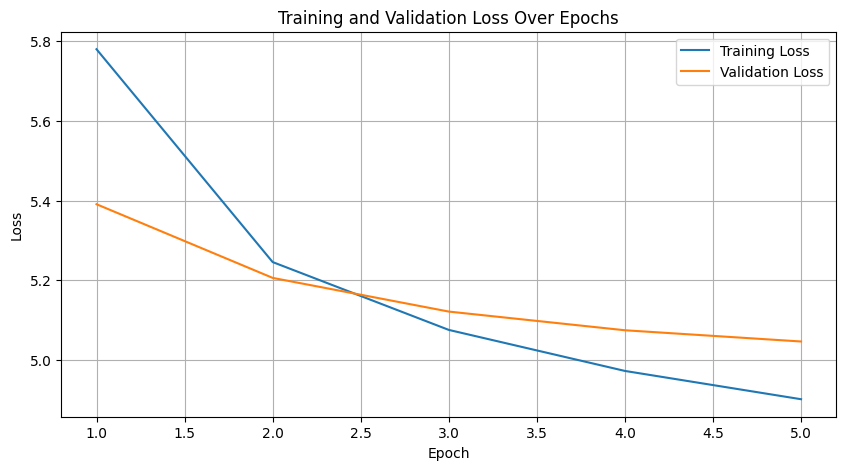

In [18]:
# Plot training and validation losses for all epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), trn_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Inference

In [19]:
# predict next few (nwords) words, given a sentence
def next(sentence, nwords=3):
    words = word_tokenize(sentence)
    inp = torch.tensor([vocab[w] for w in words[-5:]], device=device)
    model.eval()
    for _ in range(nwords):
        with torch.no_grad():
            pred = model(inp).detach().cpu()
            options = torch.topk(pred, 3).indices # find top 3 words
            print(vocab.totext(options))
            nxt = torch.argmax(pred)
            # print(vocab.totext([nxt]))
            inp = torch.cat([inp[1:], torch.tensor([nxt]).to(device)]) # remove first word and append best prediction

In [21]:
# Minimum 5 words
next("The movie was really great", 15)

['.', ',', 'and']
['The', 'I', 'It']
['film', 'story', 'movie']
['is', 'was', 'has']
['a', "n't", 'not']
['very', 'great', 'good']
['good', 'bad', 'interesting']
['movie', 'film', 'and']
['.', ',', 'that']
['I', 'The', 'It']
["'m", 'do', 'think']
['not', 'sure', 'a']
['sure', 'a', 'even']
['that', 'if', 'why']
['it', 'I', 'the']
